# 3. Temporal entropies and the entropy route to $c$

We cut the pair of temporal boundary states at a time site $t$ and trace out everything past the
cut. The resulting object is the reduced transition matrix, and the Rényi-2 entropy built from it is
complex. Boundary CFT predicts both parts,

$$\operatorname{Re}S_2(t) = s_0 + \frac{c}{8}\,W(t,T), \qquad
  \operatorname{Im}S_2(t) = \frac{\pi c}{16},$$

with the chord variable $W(t,T) = \ln\left[\tfrac{2T}{\pi}\sin\tfrac{\pi t}{T}\right]$. The real
part is a dome across the strip and the imaginary part a constant plateau, so the plateau alone
determines $c$.

We compute one profile here, then use the cached production ladders to follow the plateau to long
times and extract $c$.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Statistics, LsqFit
thesis_plot_theme!()

## One profile

A rung of the ladder is one power iteration on the transfer-matrix column. `run_pm_diagnosed` builds
$U(\delta t)$ as an MPO, rotates it into the column and iterates to the dominant left and right
pair; `gen_renyi2` returns the entropy profile from that pair. At $p = 0$ and $T = 3$ with a small
bond dimension this takes a few seconds. The iteration log below shows `ds` decreasing until the run
converges.

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=34, cutoff=1.0e-14, maxdim=32, normalize=overlap)   2%  ETA: 0:00:36 ( 7.41 ms/it)
   Info: [102]  chi=6 | ds=4.4162408754377935e-6 | <R|Rprev> = NaN

converged in 105 iterations, chi = 6, |mu0| = 1.49225
plateau of Im S2 = 0.1317   (CFT target pi c/16 = 0.0982)


[ Info: PM Converged after 105 steps | ds=6.358687547614039e-7 | chi=6)


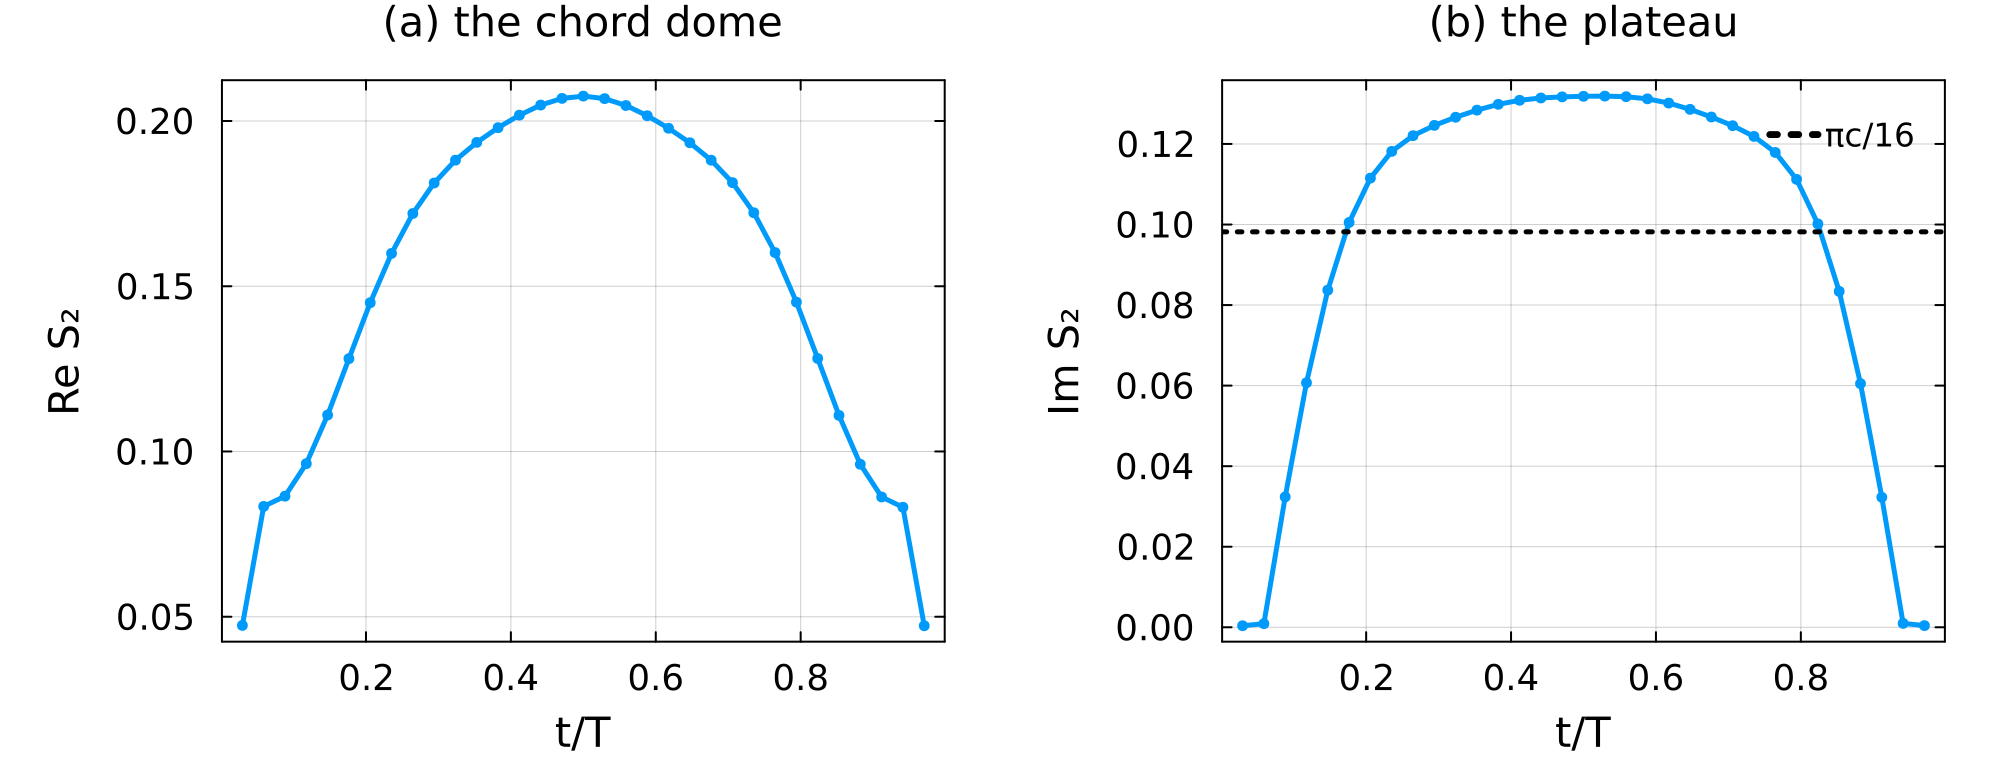

In [2]:
r  = run_pm_diagnosed(3.0; p=0.0, dt=0.1, nbeta=4, maxdim=32, column=:bulk5)
s2 = collect(ITransverse.gen_renyi2(r.L, r.R))

@printf("converged in %d iterations, chi = %d, |mu0| = %.5f\n",
        r.niters, maxlinkdim(r.R), abs(r.lambda0))
@printf("plateau of Im S2 = %.4f   (CFT target pi c/16 = %.4f)\n", plateau_im(s2, 4), pi / 32)

ts = (1:length(s2)) ./ (length(s2) + 1)
pa = plot(ts, real.(s2); marker=:circle, ms=3, msw=0, label="", xlabel="t/T", ylabel="Re S₂",
          title="(a) the chord dome")
pb = plot(ts, imag.(s2); marker=:circle, ms=3, msw=0, label="", xlabel="t/T", ylabel="Im S₂",
          title="(b) the plateau")
hline!(pb, [pi / 32]; ls=:dot, color=:black, label="πc/16")
plot(pa, pb; layout=(1, 2), size=(1000, 380), margin=5Plots.mm)

Both shapes are present already at $T = 3$: a dome in the real part and a flat interior in the
imaginary part, sitting above its predicted value. The production runs use the same call at larger
$T$, bond dimension 64 and twenty random seeds per time, which is why they were run on the cluster.
The figure below collects them.

T= 6  plateau = 0.1296
T= 8  plateau = 0.1239


T=10  plateau = 0.1202
T=12  plateau = 0.1211
T=13  plateau = 0.1154
target πc/16 at c=1/2 = 0.0982


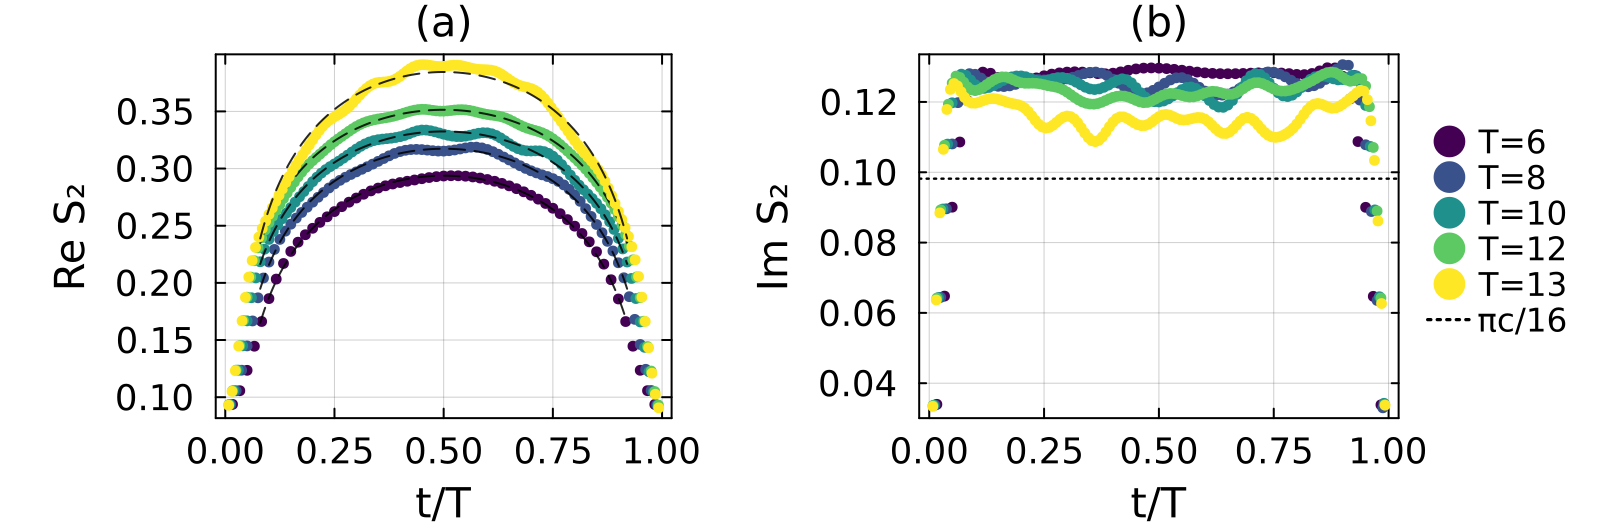

In [3]:
include("../scripts/figures/fig_domes.jl")
make_domes()

## Where the usable window ends

Each ladder stops at a time beyond which the profiles are no longer conformal. The mechanism is the
same one that makes the method work. As $T$ grows the moduli of the leading eigenvalues collapse
onto a single circle, so the separations between neighbouring eigenvalues shrink. The sensitivity of
an eigenvector to a perturbation goes as one over that separation, while an eigenvalue obtained by
projecting onto the subspace is second-order accurate in the error of the vectors spanning it. The
entropy route needs the eigenvectors, so it fails first, and the spectral route of notebook 4
reaches further.

This does not explain why the window shortens so quickly with the coupling. The thesis diagonalises
the rotated column densely, with no truncation: the separation between the two leading eigenvalues
stays near 0.2 at every coupling, while the condition number of the eigenvector basis increases by
seven to nine orders of magnitude as soon as $p \neq 0$. The window therefore does not close because
the spectrum becomes degenerate. Why the coupling controls the conditioning is left open.

## Profiles past the window

The $p = 0$ production arm reaches $T = 18$, but the profiles stay conformal only to about
$T = 15$. Below we compare two clean profiles with two broken ones from the same arm, at the same
settings. Past the window the profile is no longer a dome and no fit recovers it.

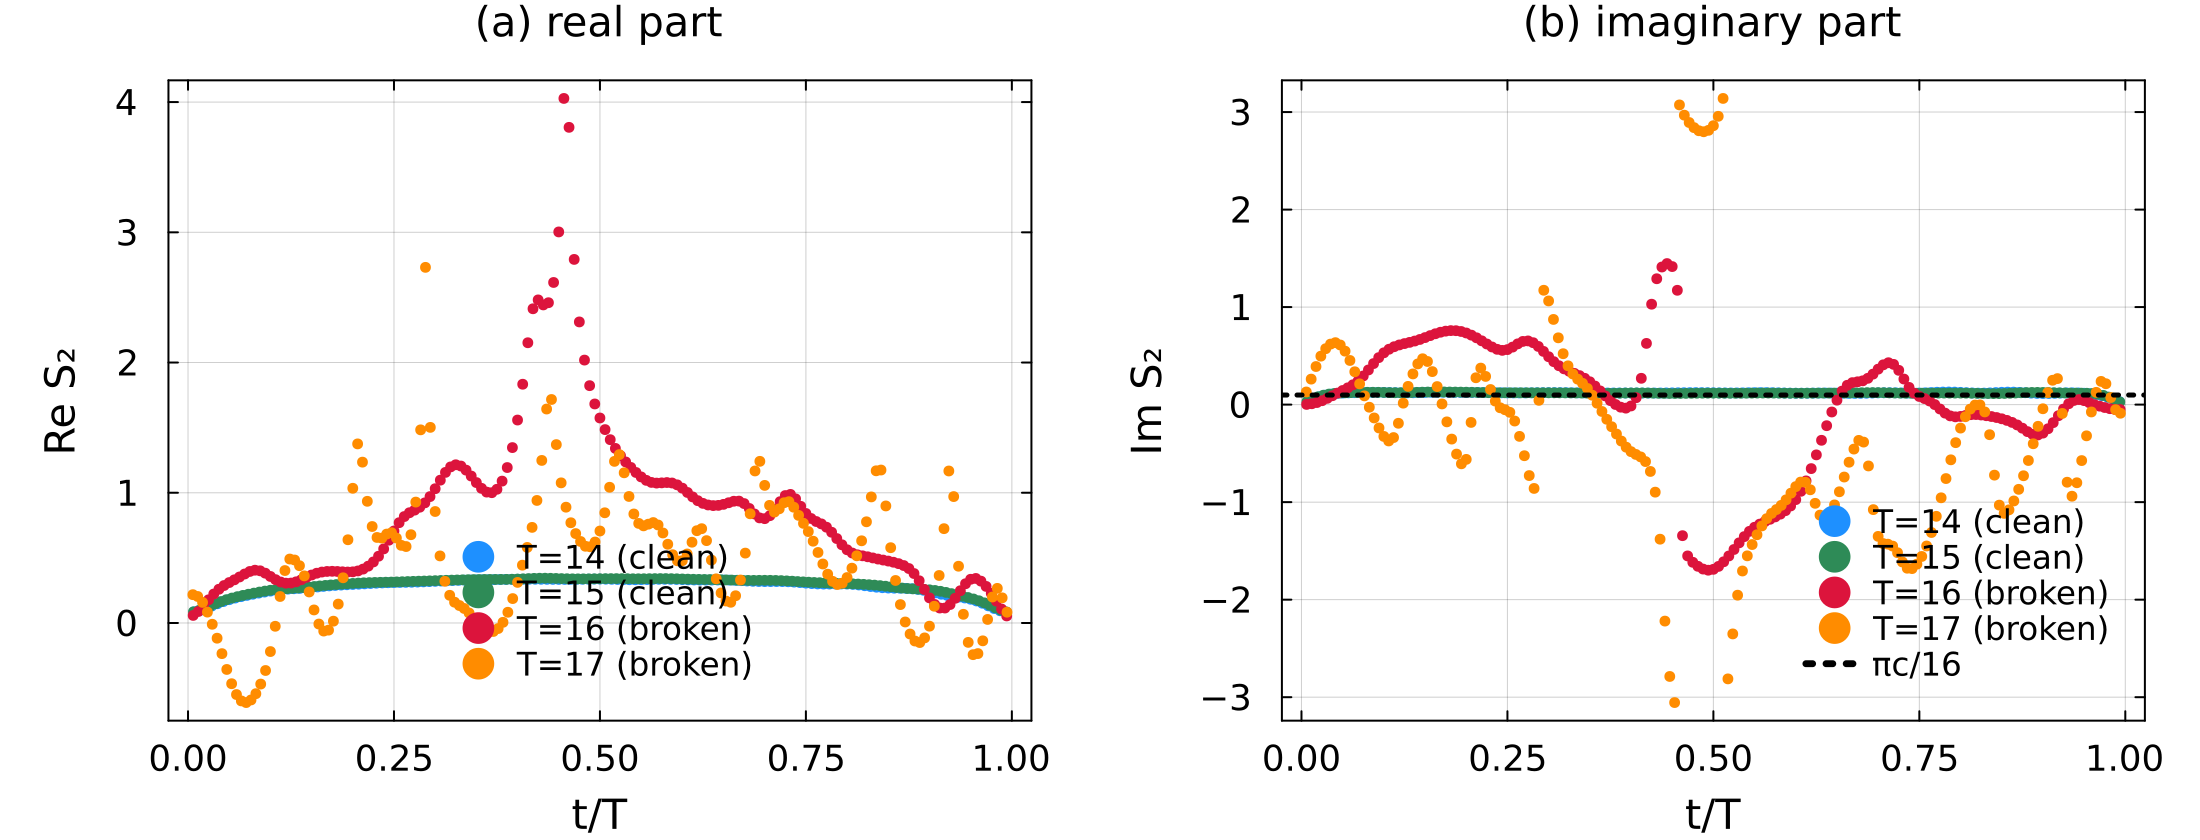

In [5]:
# clean versus broken profiles from the same cluster arm (p=0, corrected data)
arm(file, label) = Dict(k[2] => v for (k, v) in load(joinpath("../data/cluster", file), "done")
                        if k[1] == label && !haskey(v, :error) && !isempty(v.s2_base))
a0 = arm("sweep_ent_p0.0.jld2", "ent_p0.0")
avail = sort(collect(keys(a0)))
clean  = [T for T in (14.0, 15.0) if T in avail]
broken = [T for T in avail if T > 15.0][1:min(2, end)]

pa = plot(xlabel="t/T", ylabel="Re S₂", legend=:bottom, title="(a) real part")
pb = plot(xlabel="t/T", ylabel="Im S₂", legend=:bottomright, title="(b) imaginary part")
for (Tset, cols, tag) in ((clean, (:dodgerblue, :seagreen), "clean"),
                          (broken, (:crimson, :darkorange), "broken"))
    for (T, col) in zip(Tset, cols)
        s2 = a0[T].s2_base
        n = length(s2)
        ts = range(T / (n + 1), T - T / (n + 1), length=n) ./ T
        scatter!(pa, ts, real.(s2), color=col, ms=3, msw=0, label="T=$(Int(T)) ($tag)")
        scatter!(pb, ts, imag.(s2), color=col, ms=3, msw=0, label="T=$(Int(T)) ($tag)")
    end
end
hline!(pb, [pi / 32], color=:black, ls=:dot, label="πc/16")
plot(pa, pb, layout=(1, 2), size=(1100, 420), margin=5Plots.mm)

## From the plateau to $c$

The estimator is the plateau rather than the dome, and the extraction has three steps. Each accepted
run gives one plateau, the average of $\operatorname{Im}S_2$ over the four temporal bonds at the
centre of the strip. The value at a given time is the median over the runs of that time's seed
ensemble, rejecting runs whose plateau falls outside $(0.05, 0.20)$ as unphysical. The plateau
approaches $\pi c/16$ from above as the finite-time correction decays, so fitting
$\mathrm{plateau}(T) = a + b\,T^{-1/2}$ across the window gives $c = 16a/\pi$ from the asymptote.

The cell below performs all three steps on the seed ensembles at $p = 0$ and reproduces the value in
the results table.

T =  4.0   20 runs kept   plateau = 0.1318
T =  5.0   20 runs kept   plateau = 0.1298


T =  6.0   20 runs kept   plateau = 0.1273
T =  7.0   20 runs kept   plateau = 0.1274
T =  8.0   20 runs kept   plateau = 0.1252
T = 10.0   20 runs kept   plateau = 0.1209
T = 12.0   20 runs kept   plateau = 0.1191
T = 14.0   20 runs kept   plateau = 0.1186
T = 16.0   20 runs kept   plateau = 0.1153
T = 17.0   20 runs kept   plateau = 0.1137
T = 18.0   19 runs kept   plateau = 0.1144
T = 20.0   20 runs kept   plateau = 0.1146
T = 22.0   18 runs kept   plateau = 0.1080

asymptote a = 0.09639   ->   c = 16a/pi = 0.4909     (Ising: 0.5)


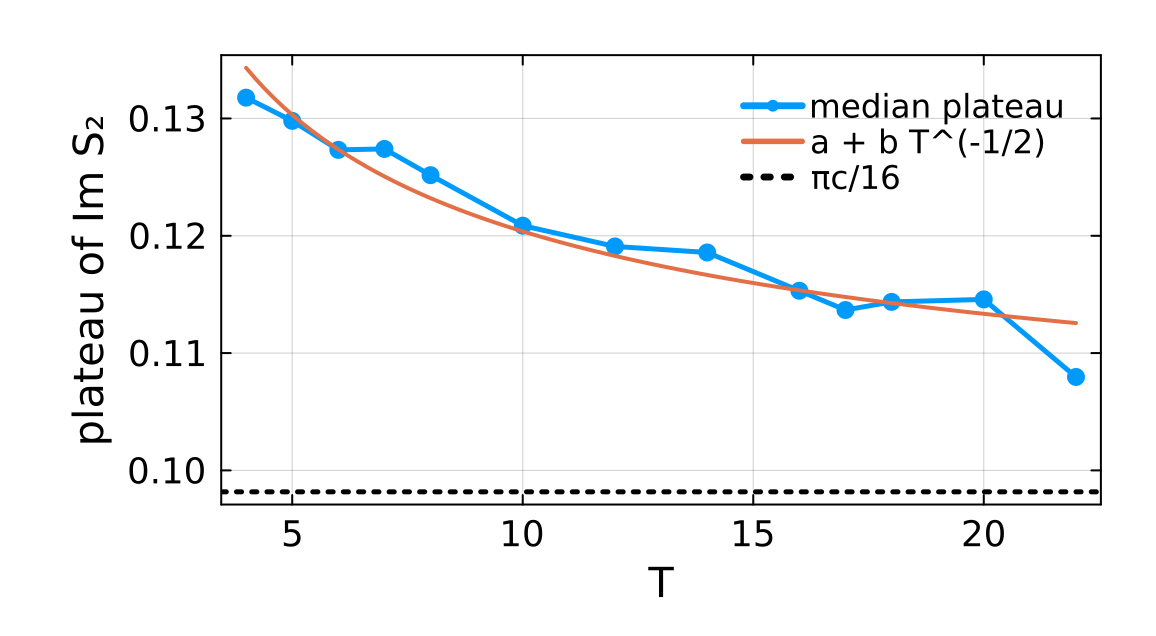

In [6]:
# one plateau per accepted run, median per rung, then the extrapolation
function rung(p, T)
    f = "../data/local/controls/seedens_p$(p)_T$(T).jld2"
    isfile(f) || return nothing
    keep = filter(x -> 0.05 < x < 0.20, [r.plateau for r in values(load(f, "res"))])
    return length(keep) >= 3 ? (median(keep), length(keep)) : nothing
end

Ts, ms = Float64[], Float64[]
for T in 4.0:1.0:22.0
    v = rung(0.0, T)
    v === nothing && continue
    push!(Ts, T); push!(ms, v[1])
    @printf("T = %4.1f   %2d runs kept   plateau = %.4f\n", T, v[2], v[1])
end

@. decay(T, q) = q[1] + q[2] / sqrt(T)
fit = curve_fit(decay, Ts, ms, [0.1, 0.05])
@printf("\nasymptote a = %.5f   ->   c = 16a/pi = %.4f     (Ising: 0.5)\n",
        fit.param[1], 16 * fit.param[1] / pi)

pl = plot(Ts, ms; marker=:circle, ms=5, msw=0, label="median plateau", xlabel="T",
          ylabel="plateau of Im S₂", size=thesis_size(0.75; aspect=0.55))
plot!(pl, 4:0.2:22, decay(collect(4:0.2:22), fit.param); lw=2, label="a + b T^(-1/2)")
hline!(pl, [pi / 32]; ls=:dot, color=:black, label="πc/16")

The quoted uncertainty comes from the same ensembles. We resample each rung's accepted runs with
replacement, take the median again, refit the ladder, and take the standard deviation of $c$ over
the replicas. This gives $0.49 \pm 0.01$ here and $\pm 0.04$ at the interacting couplings, where
fewer rungs support the fit. `scripts/analysis/table1_errors.jl` performs it for all four couplings.

## The same measurement at every coupling

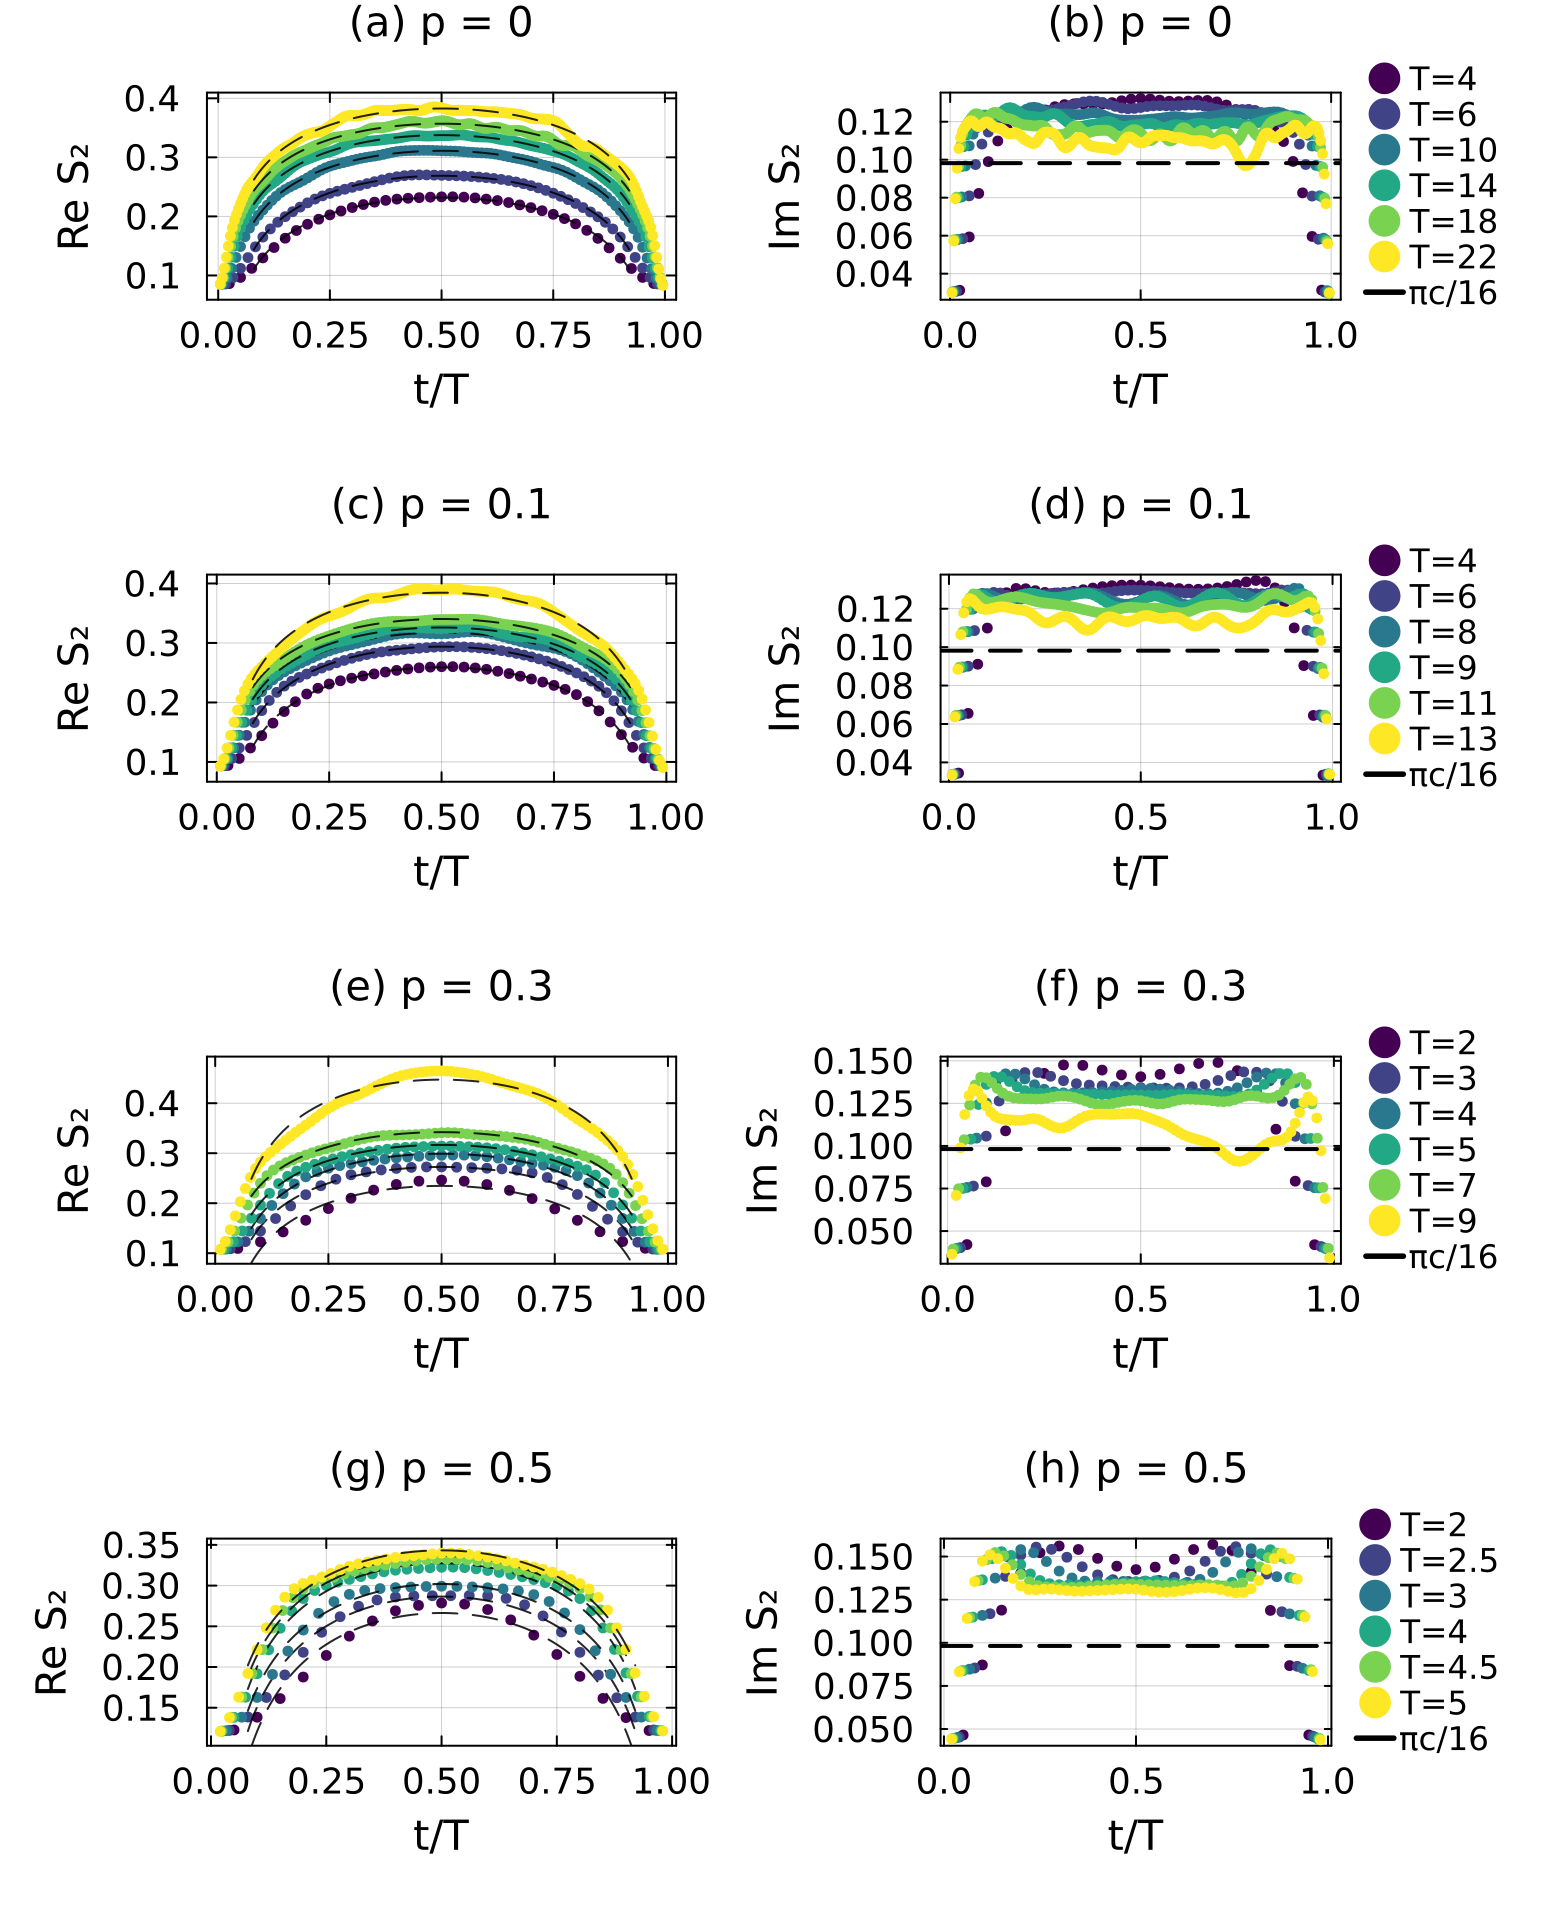

In [7]:
include("../scripts/figures/fig_domes_hi.jl")
make_domes_hi()

The structure is the same at every coupling: a dome in the real part and an interior plateau in the
imaginary part approaching $\pi c/16$. What changes is the reach, $T \le 22, 13, 9, 5$ as $p$ goes
from 0 to 0.5. Measured in conformal units $v_\infty T$ the four windows are considerably closer
than they appear, which is why the same form applies to all of them.

## Why we do not fit the real part

The dome also contains $c$, in its slope $c/8$, but it cannot be used for the measurement. Over the
accessible strip the logarithm and the finite-time correction that accompanies it have nearly the
same shape, with a regressor correlation of $-0.9997$, so any change in $c$ is absorbed by the
correction amplitude. Fixing $c = 1/2$ reproduces the residuals of the free fit from about $T = 12$
onwards, which shows that the flat direction is real.

T=14: c_unc=0.602  c_corr=0.510  a_pin=-0.0876
c_unc range 0.444..0.735 ; c_corr range 0.175..1.479


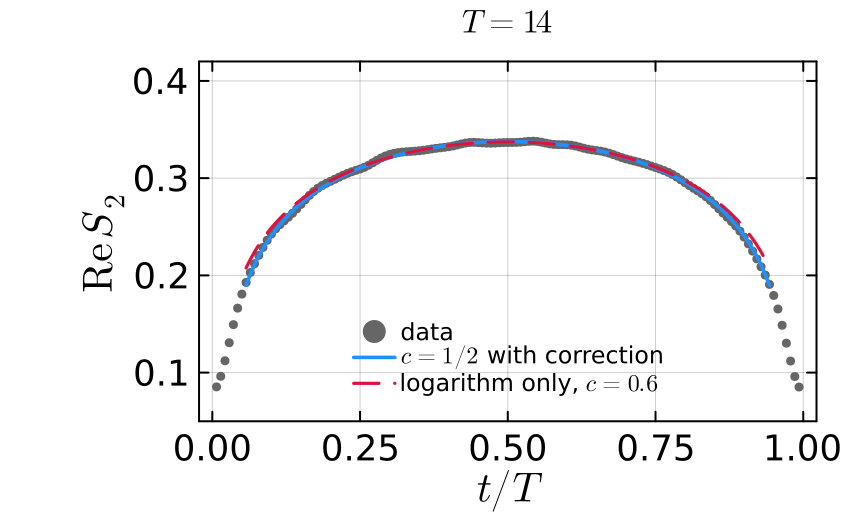

In [8]:
include("../scripts/figures/fig_re_c.jl")
make_re_c()

The entropy route therefore rests on the plateau. It gives $c$ consistent with the Ising value at
$p = 0$ and $p = 0.1$, and estimates above it at $p = 0.3$ and $p = 0.5$, where the window closes
before the finite-time correction has decayed. Notebook 4 uses the second route, which needs no
eigenvectors and reaches longer times.